In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
!git clone https://github.com/flyakon/AgriFM.git
%cd AgriFM

# torch 2.2.2 + cu121 (cp312 휠 존재)
!pip install -q torch==2.2.2 torchvision==0.17.2 --index-url https://download.pytorch.org/whl/cu121

# mmcv 2.2.0 — torch2.2 / cu121 휠 인덱스 (빌드 없음)
!pip install -q mmcv==2.2.0 -f https://download.openmmlab.com/mmcv/dist/cu121/torch2.2.0/index.html

# 나머지
!pip install -q mmengine ftfy tqdm regex h5py prettytable timm scipy einops "numpy<2"
print("✅ 설치 끝 — 검증 셀로")

fatal: destination path 'AgriFM' already exists and is not an empty directory.
/content/AgriFM
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 757.2/757.2 MB 817.3 kB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 26.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 82.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 58.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 107.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 731.7/731.7 MB 1.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 3.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 7.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 MB 13.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.2/124.2 MB 7.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.0/196.0 MB 6.0 MB/s eta 0:00:00
     ━━━━━━━━━━━

In [3]:
import torch, mmcv, mmengine
print("torch", torch.__version__, "| cuda", torch.cuda.is_available())
print("mmcv", mmcv.__version__, "| mmengine", mmengine.__version__)

torch 2.2.2+cu121 | cuda True
mmcv 2.2.0 | mmengine 0.10.7


In [4]:
import zipfile, os, glob, h5py

zip_path = "/content/drive/MyDrive/example_dataset.zip"   # 경로 다르면 수정
os.makedirs("/content/AgriFM/example_dataset", exist_ok=True)
with zipfile.ZipFile(zip_path) as z:
    z.extractall("/content/AgriFM/example_dataset")
print("압축 해제 완료\n")

# 풀린 구조 확인
for p in sorted(glob.glob("/content/AgriFM/example_dataset/**", recursive=True))[:25]:
    print(p)

# h5 하나 열어서 실제 shape (분석 확증)
h5s = glob.glob("/content/AgriFM/example_dataset/**/*.h5", recursive=True)
print("\nh5 개수:", len(h5s))
if h5s:
    with h5py.File(h5s[0], "r") as f:
        print("keys:", list(f.keys()))
        for k in f.keys():
            print(f"  {k}: {f[k].shape}")

압축 해제 완료

/content/AgriFM/example_dataset/
/content/AgriFM/example_dataset/example_dataset
/content/AgriFM/example_dataset/example_dataset/data_list
/content/AgriFM/example_dataset/example_dataset/data_list/test.txt
/content/AgriFM/example_dataset/example_dataset/data_list/train.txt
/content/AgriFM/example_dataset/example_dataset/data_list/val.txt
/content/AgriFM/example_dataset/example_dataset/h5_samples
/content/AgriFM/example_dataset/example_dataset/h5_samples/2018_T31TDK_10752_3328.h5
/content/AgriFM/example_dataset/example_dataset/h5_samples/2018_T31TDK_2560_2304.h5
/content/AgriFM/example_dataset/example_dataset/h5_samples/2018_T31TDK_2816_0768.h5
/content/AgriFM/example_dataset/example_dataset/h5_samples/2018_T31TDK_3072_0512.h5
/content/AgriFM/example_dataset/example_dataset/h5_samples/2018_T31TDK_3328_2304.h5
/content/AgriFM/example_dataset/example_dataset/h5_samples/2018_T31TDK_3328_2816.h5
/content/AgriFM/example_dataset/example_dataset/h5_samples/2018_T31TDK_3328_4352.h5
/c

In [5]:
# config에서 경로/체크포인트 관련 줄만 추출
import re
cfg_path = "/content/AgriFM/configs/cropland_mapping.py"
with open(cfg_path) as f:
    lines = f.readlines()

print(f"총 {len(lines)}줄\n--- 경로/checkpoint/dataset 관련 줄 ---")
for i, ln in enumerate(lines, 1):
    if re.search(r"(data_root|data_prefix|ann_file|data_list|h5|root|path|checkpoint|init_cfg|load_from|\.txt|max_epochs|epoch|batch_size)", ln, re.I):
        print(f"{i:4d}| {ln.rstrip()}")

총 191줄
--- 경로/checkpoint/dataset 관련 줄 ---
  13| pretrained_weights_path='Path to weights/AgriFM.pth'
  14| data_path=r'Path to dataset/example_dataset/h5_samples'
  15| data_list_path=r'Path to dataset/example_dataset/data_list'
  49|     batch_size=4,
  56|         data_toot_path=data_path,
  57|         data_list_file=data_list_path+'/train.txt',
  64|     batch_size=4,
  71|         data_toot_path=data_path,
  72|         data_list_file=data_list_path + '/val.txt',
  80|     batch_size=8,
  87|         data_toot_path=data_path,
  88|         data_list_file=data_list_path + '/test.txt',
 121|                         drop_path_rate=0.2,
 124|                         use_checkpoint=False,
 128|                     init_cfg=dict(type='pretrained', checkpoint=pretrained_weights_path,
 163|          by_epoch=False,
 171|         by_epoch=False,
 177| log_processor = dict(by_epoch=True)
 182| train_cfg = dict(type='EpochBasedTrainLoop', max_epochs=50, val_interval=1)
 186|     logger=dict(

In [6]:
cfg_path = "/content/AgriFM/configs/cropland_mapping.py"
with open(cfg_path) as f:
    src = f.read()

# 1) placeholder 경로 3개를 실제 경로로 교체
src = src.replace(
    "pretrained_weights_path='Path to weights/AgriFM.pth'",
    "pretrained_weights_path='/content/drive/MyDrive/AgriFM.pth'")
src = src.replace(
    "data_path=r'Path to dataset/example_dataset/h5_samples'",
    "data_path=r'/content/AgriFM/example_dataset/example_dataset/h5_samples'")
src = src.replace(
    "data_list_path=r'Path to dataset/example_dataset/data_list'",
    "data_list_path=r'/content/AgriFM/example_dataset/example_dataset/data_list'")

# 2) 학습 짧게 (50 → 2 epoch, val 매 epoch)
src = src.replace(
    "train_cfg = dict(type='EpochBasedTrainLoop', max_epochs=50, val_interval=1)",
    "train_cfg = dict(type='EpochBasedTrainLoop', max_epochs=2, val_interval=1)")

# 새 config로 저장
new_cfg = "/content/AgriFM/configs/cropland_mapping_colab.py"
with open(new_cfg, "w") as f:
    f.write(src)

# 교체 확인
import re
for i, ln in enumerate(open(new_cfg).readlines(), 1):
    if re.search(r"(weights_path=|data_path=|data_list_path=|max_epochs)", ln):
        print(f"{i:4d}| {ln.rstrip()}")

  13| pretrained_weights_path='/content/drive/MyDrive/AgriFM.pth'
  14| data_path=r'/content/AgriFM/example_dataset/example_dataset/h5_samples'
  15| data_list_path=r'/content/AgriFM/example_dataset/example_dataset/data_list'
 182| train_cfg = dict(type='EpochBasedTrainLoop', max_epochs=2, val_interval=1)


In [8]:
import re
p = "/content/AgriFM/mmseg/__init__.py"
s = open(p).read()

# mmcv_max_version 을 2.2.0 → 2.3.0 으로 (상한 풀기)
s2 = re.sub(r"mmcv_max_version\s*=\s*digit_version\(['\"][\d.]+['\"]\)",
            "mmcv_max_version = digit_version('2.3.0')", s)
open(p, "w").write(s2)

# 바뀐 줄 확인
for i, ln in enumerate(open(p).readlines(), 1):
    if "mmcv_min_version" in ln or "mmcv_max_version" in ln:
        print(f"{i:4d}| {ln.rstrip()}")

  56| mmcv_min_version = digit_version(MMCV_MIN)
  57| mmcv_max_version = digit_version(MMCV_MAX)
  61| assert (mmcv_min_version <= mmcv_version < mmcv_max_version), \


In [10]:
import re
p = "/content/AgriFM/mmseg/__init__.py"
s = open(p).read()

# MMCV_MAX = '2.2.0' 같은 정의를 찾아 2.3.0 으로
s2 = re.sub(r"MMCV_MAX\s*=\s*['\"][\d.]+['\"]", "MMCV_MAX = '2.3.0'", s)
open(p, "w").write(s2)

# MMCV_MIN / MMCV_MAX 정의 줄 확인
for i, ln in enumerate(open(p).readlines(), 1):
    if "MMCV_MAX" in ln or "MMCV_MIN" in ln:
        print(f"{i:4d}| {ln.rstrip()}")

  10| MMCV_MIN = '2.0.0rc4'
  11| MMCV_MAX = '2.3.0'
  56| mmcv_min_version = digit_version(MMCV_MIN)
  57| mmcv_max_version = digit_version(MMCV_MAX)


In [12]:
new_cfg = "/content/AgriFM/configs/cropland_mapping_colab.py"
s = open(new_cfg).read()

# LinearLR warmup end: 1000 → 20 (총 44 iter보다 작게)
s = s.replace("begin=0, by_epoch=False, end=1000, start_factor=0.01",
              "begin=0, by_epoch=False, end=20, start_factor=0.01")
# CosineAnnealing begin: 1000 → 20 (warmup 끝과 맞춤)
s = s.replace("begin=1000, by_epoch=False, eta_min=1e-06",
              "begin=20, by_epoch=False, eta_min=1e-06")

open(new_cfg, "w").write(s)

# 확인
import re
for i, ln in enumerate(open(new_cfg).readlines(), 1):
    if "begin=" in ln and ("LinearLR" in ln or "Cosine" in ln or "end=" in ln or "eta_min" in ln):
        print(f"{i:4d}| {ln.rstrip()}")

In [14]:
new_cfg = "/content/AgriFM/configs/cropland_mapping_colab.py"
s = open(new_cfg).read()

# 혹시 이전 치환이 안 먹었을 수 있으니 1000 → 20 강제 치환 (정확 매칭)
s = s.replace("end=1000", "end=20")
s = s.replace("begin=1000", "begin=20")

open(new_cfg, "w").write(s)

# ★ 진짜 바뀌었는지 파일에서 다시 읽어 확인
import re
print("=== param_scheduler 관련 줄 ===")
for i, ln in enumerate(open(new_cfg).readlines(), 1):
    if "begin=" in ln or "end=" in ln and ("Linear" in ln or "Cosine" in ln):
        print(f"{i:4d}| {ln.rstrip()}")
print("\n파일에 '1000' 남아있나?:", "1000" in open(new_cfg).read())

=== param_scheduler 관련 줄 ===
 164|          begin=0,
 172|         begin=20,

파일에 '1000' 남아있나?: False


In [16]:
new_cfg = "/content/AgriFM/configs/cropland_mapping_colab.py"
s = open(new_cfg).read()

# 1) batch_size 4→1, 8→1 (test 포함 전부 1로)
s = s.replace("batch_size=4,", "batch_size=1,")
s = s.replace("batch_size=8,", "batch_size=1,")
# 2) num_workers 줄이기 (경고 + 메모리 절약)
s = s.replace("num_workers=8,", "num_workers=2,")
s = s.replace("num_workers=6,", "num_workers=2,")
# 3) epoch 2→1 (한 바퀴면 결과 충분)
s = s.replace("max_epochs=2,", "max_epochs=1,")
# 4) scheduler end도 batch=1이면 iter 늘어나니 안전하게 유지 (end=20 그대로 OK)

open(new_cfg, "w").write(s)

# 확인
import re
for i, ln in enumerate(open(new_cfg).readlines(), 1):
    if re.search(r"(batch_size=|num_workers=|max_epochs)", ln):
        print(f"{i:4d}| {ln.rstrip()}")
print("\n'1000' 남음?:", "1000" in open(new_cfg).read())

  49|     batch_size=1,
  50|     num_workers=2,
  64|     batch_size=1,
  65|     num_workers=2,
  80|     batch_size=1,
  81|     num_workers=2,
 182| train_cfg = dict(type='EpochBasedTrainLoop', max_epochs=1, val_interval=1)

'1000' 남음?: False


In [17]:
import torch, gc
gc.collect(); torch.cuda.empty_cache()

%cd /content/AgriFM
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"
!PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True python train.py configs/cropland_mapping_colab.py --work-dir ./work_dirs/colab

/content/AgriFM
/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
05/26 10:00:53 - mmengine - INFO - 
------------------------------------------------------------
System environment:
    sys.platform: linux
    Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
    CUDA available: True
    MUSA available: False
    numpy_random_seed: 1918066215
    GPU 0: Tesla T4
    CUDA_HOME: /usr/local/cuda
    NVCC: Cuda compilation tools, release 12.8, V12.8.93
    GCC: x86_64-linux-gnu-gcc (Ubuntu 11.4.0-1ubuntu1~22.04.3) 11.4.0
    PyTorch: 2.2.2+cu121
    PyTorch compiling details: PyTorch built with:
  - GCC 9.3
  - C++ Version: 201703
  - Intel(R) oneAPI Math Kernel Library Version 2022.2-Product Build 20220804 for Intel(R) 64 architecture applications
  - Intel(

In [18]:
%cd /content/AgriFM
!python test.py configs/cropland_mapping_colab.py work_dirs/colab/best_mFscore_epoch_1.pth

/content/AgriFM
/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
05/26 10:10:59 - mmengine - INFO - 
------------------------------------------------------------
System environment:
    sys.platform: linux
    Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
    CUDA available: True
    MUSA available: False
    numpy_random_seed: 1929446948
    GPU 0: Tesla T4
    CUDA_HOME: /usr/local/cuda
    NVCC: Cuda compilation tools, release 12.8, V12.8.93
    GCC: x86_64-linux-gnu-gcc (Ubuntu 11.4.0-1ubuntu1~22.04.3) 11.4.0
    PyTorch: 2.2.2+cu121
    PyTorch compiling details: PyTorch built with:
  - GCC 9.3
  - C++ Version: 201703
  - Intel(R) oneAPI Math Kernel Library Version 2022.2-Product Build 20220804 for Intel(R) 64 architecture applications
  - Intel(

In [21]:
%cd /content/AgriFM
!python inference.py configs/cropland_mapping_colab.py work_dirs/colab/best_mFscore_epoch_1.pth ./vis_results

/content/AgriFM
/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/usr/local/lib/python3.12/dist-packages/torch/functional.py:507: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3549.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
Loads checkpoint by local backend from path: /content/drive/MyDrive/AgriFM.pth
The model and loaded state dict do not match exactly

unexpected key in source state_dict: encoder.HLSL30_patch_emd.weights, encoder.HLSL30_patch_emd.bias, encoder.patch_emd.weights, encoder.patch_emd.bias, encoder.Modis_patch_emd.weights, encoder.Modis_patch_emd.bias, encoder.backbone.layers.0.blocks.0.norm1.weight,

In [20]:
# config 맨 끝에 result_path 추가
with open('configs/cropland_mapping_colab.py', 'a') as f:
    f.write("\nresult_path = './vis_results'\n")

import os
os.makedirs('./vis_results', exist_ok=True)
print('✅ result_path 추가 완료')

✅ result_path 추가 완료


In [23]:
import os
print(os.listdir('/content/AgriFM/vis_results'))  # 저장된 png 목록 확인

['2018_T31TDK_2816_0768_pred.png', '2018_T31TDL_6656_0000_pred.png', '2018_T31TDM_8448_9984_pred.png', '2018_T31TDK_9728_5632_pred.png', '2018_T31TDL_10240_0000_pred.png', '2018_T31TDL_10496_1024_pred.png', '2018_T31TDM_9216_7168_pred.png', '2018_T31TDM_10496_5376_pred.png', '2018_T31TDK_4352_1536_pred.png', '2018_T31TDL_10752_1280_pred.png', '2018_T31TDM_6656_8960_pred.png', '2018_T31TDK_4096_3328_pred.png', '2018_T31TDK_5632_3840_pred.png', '2018_T31TDK_4864_4864_pred.png', '2018_T31TDM_10240_5376_pred.png', '2018_T31TDL_6400_3584_pred.png', '2018_T31TDM_9216_5632_pred.png', '2018_T31TDL_6912_2560_pred.png', '2018_T31TDL_4608_7936_pred.png', '2018_T31TDL_8192_1024_pred.png', '2018_T31TDL_3072_10496_pred.png', '2018_T31TDM_6912_6144_pred.png', '2018_T31TDL_10752_1792_pred.png', '2018_T31TDL_6912_8448_pred.png', '2018_T31TDL_10752_2048_pred.png', '2018_T31TDM_10752_2304_pred.png', '2018_T31TDM_9984_7936_pred.png', '2018_T31TDL_9984_0768_pred.png', '2018_T31TDL_7424_0512_pred.png', '201

저장된 예측맵: 196개


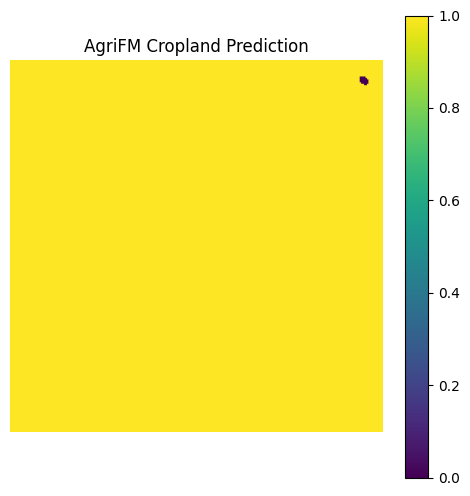

In [24]:
import glob, h5py
import numpy as np
import matplotlib.pyplot as plt

# 예측 png 대신, 모델이 본 입력+예측을 직접 시각화
preds = sorted(glob.glob('/content/AgriFM/vis_results/*.png'))
print(f"저장된 예측맵: {len(preds)}개")

# 첫 예측맵을 컬러맵 입혀서 표시
from PIL import Image as PILImage
arr = np.array(PILImage.open(preds[0]))
plt.figure(figsize=(6,6))
plt.imshow(arr, cmap='viridis')  # 0/1을 색으로 구분
plt.title('AgriFM Cropland Prediction')
plt.colorbar(); plt.axis('off')
plt.show()

In [25]:
!cat /content/AgriFM/inference.py

# -*- coding: utf-8 -*-
# @Time    : 10/12/2024 6:32 pm
# @Author  : Wenyuan Li
# @File    : inference_vis.py
# @Description :
import os
import numpy as np
import torch
import cv2
from mmseg.registry import MODELS,DATASETS
from AgriFM.utils import path_utils
import argparse
from mmengine.config import Config, DictAction
import torch.utils.data as data_utils
#import load_checkpoint in mmseg
from mmengine.runner import load_state_dict,load_checkpoint
import tqdm
from skimage import io
import copy
def parse_args():
    parser = argparse.ArgumentParser(
        description='MMSeg test (and eval) a model')
    parser.add_argument('config', help='train config file path')
    parser.add_argument('checkpoint', help='checkpoint file')
    parser.add_argument('result_path', help='path to save the inference results')
    args=parser.parse_args()
    return args

if __name__=='__main__':
    args=parse_args()
    config_file=args.config
    checkpoint_file=args.checkpoint

    options=["TILED=TRUE

예측맵 196개 발견


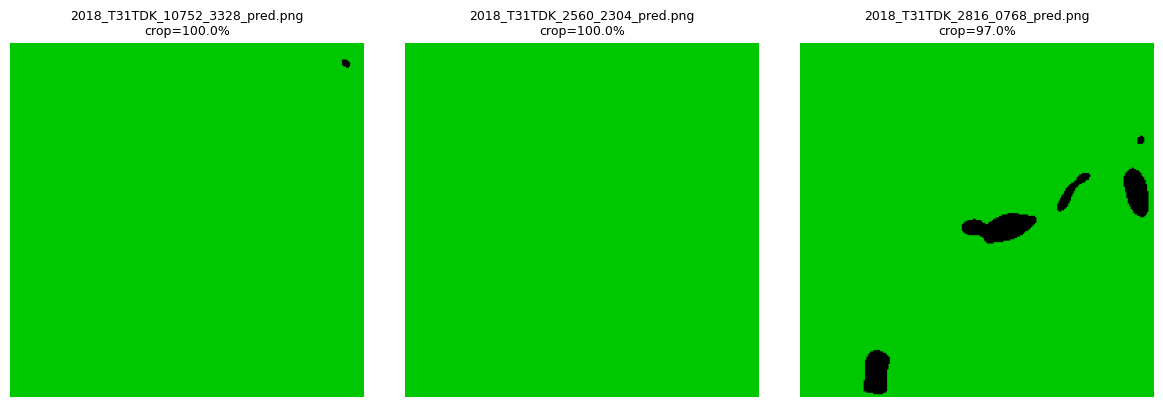

✅ 미리보기 저장 → prediction.png


In [28]:
import glob, os
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

vis_dir = '/content/AgriFM/vis_results'
preds = sorted(glob.glob(f'{vis_dir}/*_pred.png'))
print(f"예측맵 {len(preds)}개 발견")

# 0/1 라벨 → 색: 비작물=검정, 작물=초록
palette = np.array([[0,0,0],[0,200,0]], dtype=np.uint8)

# 처음 3장 표시
fig, axes = plt.subplots(1, 3, figsize=(12,4))
for ax, p in zip(axes, preds[:3]):
    m = np.array(Image.open(p))
    m = (m > 0).astype(int)              # 0/1로 정규화
    ax.imshow(palette[m])
    ax.set_title(f'{os.path.basename(p)}\ncrop={100*m.mean():.1f}%', fontsize=9)
    ax.axis('off')
plt.tight_layout()
plt.savefig('/content/AgriFM/prediction.png', dpi=120, bbox_inches='tight')
plt.show()
print("✅ 미리보기 저장 → prediction.png")